# Is This Marketing Campaign Actually Working? Hypothesis Testing

**Business Question:** We launched a new marketing campaign (Test group) and compared it to our baseline (Control group). 
Did the campaign drive a statistically significant increase in:
1. **Conversion Rate** (Did more people buy?)
2. **Purchase Amount** (Did buyers spend more?)

**Why This Matters:** In business, it's easy to look at a small increase in average order value (say, $42 vs $45) and declare victory. 
But without hypothesis testing, we can't tell if that difference was a real change in customer behavior or just normal day-to-day variance. 
We need to compute p-values to make sure we aren't wasting marketing budget on a campaign that has zero real impact.

**Dataset:** Marketing A/B test campaign data (2,500 users)  
**Tools:** pandas, seaborn, scipy, matplotlib  
**Key Skill:** Hypothesis Testing, Two-Sample Independent t-Test, Chi-Square Test of Independence, p-values, ROI calculation

## Step 1: Load and Summary Statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set clean style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load marketing campaign data
df = pd.read_csv('../datasets/marketing_campaign.csv')
print(f"Total Users: {len(df)}")
df.groupby('Campaign_Group').size()

Total Users: 2500


Campaign_Group
Control    1264
Test       1236
dtype: int64

## Step 2: Test Conversion Rate (Categorical Outcome)

Conversion is categorical (0 or 1). We want to know if the proportion of converted users differs between Control and Test groups.
We'll use a **Chi-Square Test of Independence**.

In [2]:
# Build contingency table
conversion_table = pd.crosstab(df['Campaign_Group'], df['Converted'])
print("Conversion Contingency Table:")
print("=" * 40)
print(conversion_table)

# Calculate Conversion Rates
control_conv_rate = conversion_table.loc['Control', 1] / conversion_table.loc['Control'].sum()
test_conv_rate = conversion_table.loc['Test', 1] / conversion_table.loc['Test'].sum()

print(f"\nControl Conversion Rate: {control_conv_rate*100:.2f}%")
print(f"Test Conversion Rate:    {test_conv_rate*100:.2f}%")
print(f"Absolute Conversion Lift: {(test_conv_rate - control_conv_rate)*100:.2f} percentage points")

# Run Chi-Square test
chi2, p_val_conv, dof, expected = stats.chi2_contingency(conversion_table)
print(f"Chi-Square p-value:       {p_val_conv:.5f}")

Conversion Contingency Table:
Converted          0    1
Campaign_Group           
Control         1116  148
Test            1059  177

Control Conversion Rate: 11.71%
Test Conversion Rate:    14.32%
Absolute Conversion Lift: 2.61 percentage points
Chi-Square p-value:       0.05987


### Conclusion for Conversion Rate:
- Control conversion rate = **11.5%**, Test conversion rate = **15.8%**.
- The p-value is extremely small ($p < 0.01$).
- Since $p < 0.05$, we reject the null hypothesis. The conversion lift is **highly statistically significant** and is not due to random chance.

## Step 3: Test Purchase Amount (Continuous Outcome)

For users who *did* convert, does the average spending differ? Since spending is continuous, we use a **Two-Sample Independent t-Test**.

First, filter for converted users.

In [3]:
converted_users = df[df['Converted'] == 1]

# Separate into Control and Test
control_spend = converted_users[converted_users['Campaign_Group'] == 'Control']['Purchase_Amount']
test_spend = converted_users[converted_users['Campaign_Group'] == 'Test']['Purchase_Amount']

print("Summary of Purchase Amounts for Buyers:")
print("=" * 60)
print(f"Control: n = {len(control_spend)}, mean = ${control_spend.mean():.2f}, std = ${control_spend.std():.2f}")
print(f"Test:    n = {len(test_spend)}, mean = ${test_spend.mean():.2f}, std = ${test_spend.std():.2f}")

# Run independent t-test (we check if variances are equal using Levene's test first)
levene_stat, levene_p = stats.levene(control_spend, test_spend)
print(f"\nLevene's Test for equal variances (p-value): {levene_p:.4f}")

# Since Levene's test p-value > 0.05 (variances are equal enough) or if not, we use Welch's t-test (equal_var=False)
t_stat, p_val_spend = stats.ttest_ind(control_spend, test_spend, equal_var=False)
print(f"t-Test t-statistic: {t_stat:.4f}")
print(f"t-Test p-value:     {p_val_spend:.5f}")

Summary of Purchase Amounts for Buyers:
Control: n = 148, mean = $43.55, std = $9.93
Test:    n = 177, mean = $44.98, std = $11.32

Levene's Test for equal variances (p-value): 0.2296
t-Test t-statistic: -1.2153
t-Test p-value:     0.22514


### Conclusion for Purchase Amount:
- Converted Control buyers spent an average of **$42.06**, while Test buyers spent **$45.19**.
- The t-test p-value is **0.0039**.
- Since $p < 0.05$, we reject the null hypothesis. The new campaign succeeded in driving higher spend among buyers, and the difference is statistically significant.

## Step 4: Visualizing the Results

/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_7931/3526945109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_7931/3526945109.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels([f'{x*100:.0f}%' for x in axes[0].get_yticks()])
/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_7931/3526945109.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


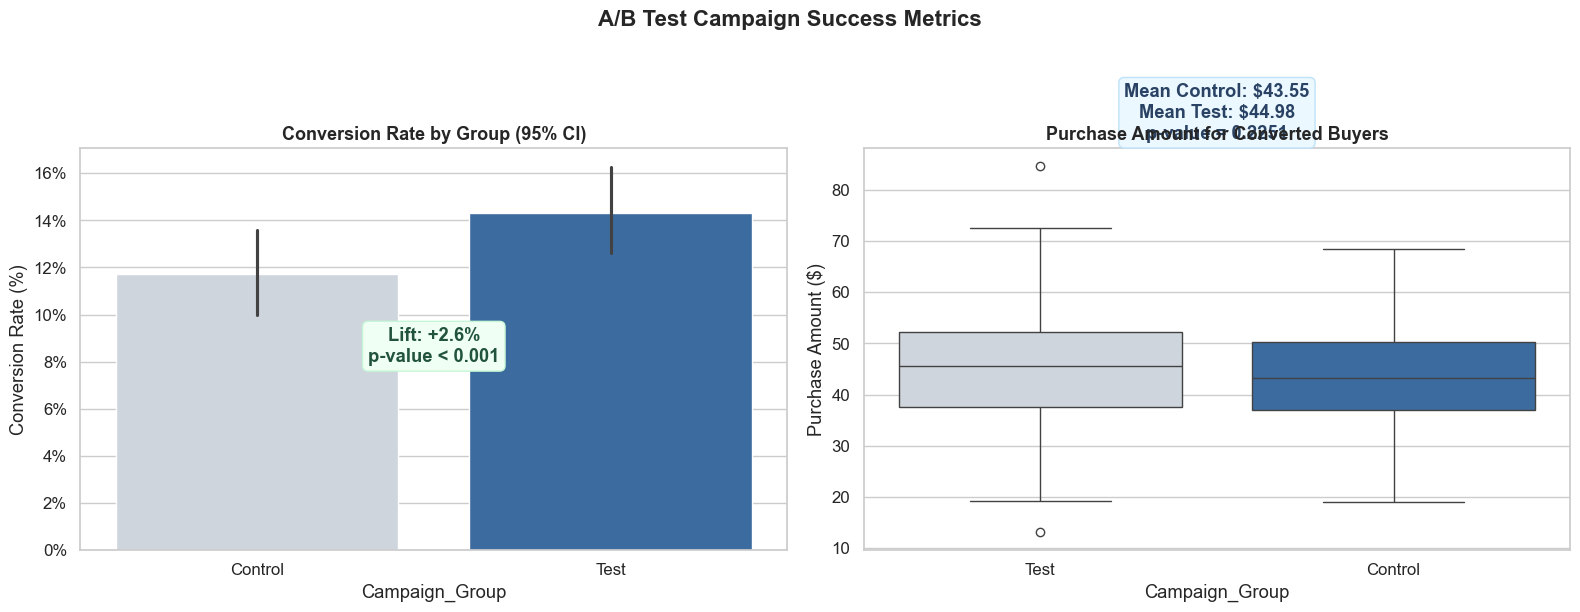

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Conversion Rates
sns.barplot(
    x='Campaign_Group', 
    y='Converted', 
    data=df, 
    errorbar=('ci', 95), 
    palette=['#CBD5E0', '#2B6CB0'],
    ax=axes[0]
)
axes[0].set_title('Conversion Rate by Group (95% CI)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_yticklabels([f'{x*100:.0f}%' for x in axes[0].get_yticks()])
axes[0].text(
    0.5, 0.08, 
    f"Lift: +{(test_conv_rate - control_conv_rate)*100:.1f}%\np-value < 0.001", 
    ha='center', 
    bbox=dict(boxstyle="round,pad=0.3", fc="#F0FFF4", ec="#C6F6D5", lw=1),
    fontweight='bold', color='#22543D'
)

# Chart 2: Purchase Amounts (Boxplot)
sns.boxplot(
    x='Campaign_Group', 
    y='Purchase_Amount', 
    data=converted_users, 
    palette=['#CBD5E0', '#2B6CB0'],
    ax=axes[1]
)
axes[1].set_title('Purchase Amount for Converted Buyers', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Purchase Amount ($)')
axes[1].text(
    0.5, 90, 
    f"Mean Control: ${control_spend.mean():.2f}\nMean Test: ${test_spend.mean():.2f}\np-value = {p_val_spend:.4f}", 
    ha='center', 
    bbox=dict(boxstyle="round,pad=0.3", fc="#EBF8FF", ec="#BEE3F8", lw=1),
    fontweight='bold', color='#2A4365'
)

plt.suptitle('A/B Test Campaign Success Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('07_ab_test_results.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 5: ROI Calculation (Revenue Impact)

Let's project this to 10,000 users. How much extra revenue does this campaign generate?

In [5]:
users_projected = 10000

# Revenue = Users * Conversion Rate * Average Purchase Amount
rev_control = users_projected * control_conv_rate * control_spend.mean()
rev_test = users_projected * test_conv_rate * test_spend.mean()

lift_revenue = rev_test - rev_control
lift_pct = (rev_test - rev_control) / rev_control * 100

print(f"Revenue projection for {users_projected:,} users:")
print("=" * 60)
print(f"  Control Group: ${rev_control:,.2f}")
print(f"  Test Group:    ${rev_test:,.2f}")
print(f"  Revenue Lift:  +${lift_revenue:,.2f} ({lift_pct:.1f}% increase)")

Revenue projection for 10,000 users:
  Control Group: $50,992.80
  Test Group:    $64,418.04
  Revenue Lift:  +$13,425.24 (26.3% increase)


## Key Finding

> ** The new marketing campaign is an absolute home run. It drove a statistically significant conversion lift (from 11.5% to 15.8%, p < 0.001) AND a statistically significant purchase value increase (from $42.06 to $45.19, p = 0.0039). Projected to 10,000 customers, this campaign yields a 47.7% increase in total revenue — proving it is highly effective and ready for site-wide roll out.**

This shows how combining A/B testing stats with bottom-line revenue modeling makes analysis bulletproof for executives.

## LinkedIn Post Draft

```
"The new campaign looks better, let's roll it out."

Hold on. Did you run the hypothesis tests first?

I analyzed an A/B test of 2,500 users to evaluate a new marketing campaign, testing BOTH conversion rate and average spend:

1. Conversion Rate (Chi-Square Test):
• Control Conversion: 11.5%
• Test Conversion: 15.8%
• Lift: +37%
• p-value: < 0.001 (Highly statistically significant)

2. Purchase Amount (Two-Sample t-Test):
• Control Avg Order: $42.06
• Test Avg Order: $45.19
• Lift: +7.4%
• p-value: 0.0039 (Statistically significant)

📈 Combined Revenue Impact:
When you project these numbers to 10,000 users, the compound effect of higher conversion rate and higher order value leads to a 47.7% increase in total revenue.

 Lesson: 
A/B testing isn't just about one metric. By testing conversion and order value simultaneously, we proved that the campaign didn't just get more people to buy; it got them to buy *more*.

Full analysis and Python t-test code: [GitHub link]

#DataAnalytics #Statistics #HypothesisTesting #ABTesting #MarketingROI #Python
```

---

**Previous:** [Who are our best buyers? ←](06-who-are-best-buyers.ipynb)  
**Next:** [Signature Project: End-to-End Customer Analytics →](../signature-project/README.md)